In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df[['Quantity', 'InvoiceDate', 'UnitPrice', 'Country', 'CustomerID']]
df.columns

Index(['Quantity', 'InvoiceDate', 'UnitPrice', 'Country', 'CustomerID'], dtype='str')

In [10]:
df.dropna(subset=['CustomerID'], axis=0, inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Quantity     401604 non-null  int64  
 1   InvoiceDate  401604 non-null  str    
 2   UnitPrice    401604 non-null  float64
 3   Country      401604 non-null  str    
 4   CustomerID   401604 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 18.4 MB


In [12]:
df['InvoiceDate'] = df['InvoiceDate'].str.strip()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format = 'mixed')

In [13]:
df['month'] = df['InvoiceDate'].dt.month
df['day'] = df['InvoiceDate'].dt.day
df['year'] = df['InvoiceDate'].dt.year

In [14]:
df.head()

,Quantity,InvoiceDate,UnitPrice,Country,CustomerID,month,day,year
0,6,2010-12-01 08:26:00,2.55,United Kingdom,17850.0,12,1,2010
1,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010
2,8,2010-12-01 08:26:00,2.75,United Kingdom,17850.0,12,1,2010
3,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010
4,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010


In [15]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,month,day,year
count,401604.000000,401604,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567,3.474064,15281.160818,7.595407,15.038623,2010.934378
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,1.000000,1.000000,2010.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13939.000000,5.000000,7.000000,2011.000000
50%,5.000000,2011-07-29 15:40:00,1.950000,15145.000000,8.000000,15.000000,2011.000000
75%,12.000000,2011-10-20 11:58:30,3.750000,16784.000000,11.000000,22.000000,2011.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,12.000000,31.000000,2011.000000
std,250.283037,NaN,69.764035,1714.006089,3.417451,8.652640,0.247620


Phát hiện bất thường trong dữ liệu trên, giá trị ở quantity < 0, trong phạm vi project mình sẽ mặc định do sai sót khi nhập liệu vô tình thêm dấu trừ, nếu trong thực tế mình sẽ đi hỏi nhân viên nhập liệu để xác nhận rồi mới xử lý tiếp. 

In [16]:
df['CustomerID'] = df['CustomerID'].astype(object)

In [17]:
df.describe(include = 'object')

C:\Users\admin\AppData\Local\Temp\ipykernel_1756\1466716981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = 'object')


,Country,CustomerID
count,401604,401604.0
unique,37,4372.0
top,United Kingdom,17841.0
freq,356728,7812.0


In [18]:
df['Country'].value_counts().to_frame().head(10)

,count
Country,
United Kingdom,356728
Germany,9480
France,8475
EIRE,7475
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1877
Portugal,1471


In [19]:
df['Country'].value_counts().to_frame().tail(10)

,count
Country,
Malta,127
United Arab Emirates,68
European Community,61
RSA,58
Lebanon,45
Lithuania,35
Brazil,32
Czech Republic,30
Bahrain,17


In [20]:
# 1. Chuyển tất cả giá trị trong cột Quantity, UnitPrice thành số dương
df['Quantity'] = df['Quantity'].abs()
df['UnitPrice'] = df['UnitPrice'].abs()

# 2. Tính toán lại cột Revenue để Revenue cũng trở thành số dương
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Kiểm tra lại kết quả
df.head()

,Quantity,InvoiceDate,UnitPrice,Country,CustomerID,month,day,year,Revenue
0,6,2010-12-01 08:26:00,2.55,United Kingdom,17850.0,12,1,2010,15.30
1,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34
2,8,2010-12-01 08:26:00,2.75,United Kingdom,17850.0,12,1,2010,22.00
3,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34
4,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34


<Axes: xlabel='month', ylabel='Revenue'>

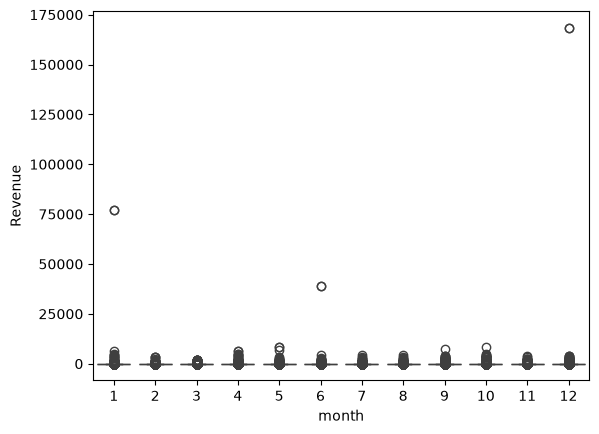

In [21]:
df['Revenue'] = df['UnitPrice'] * df['Quantity']
sns.boxplot(x=df['month'], y=df['Revenue'])

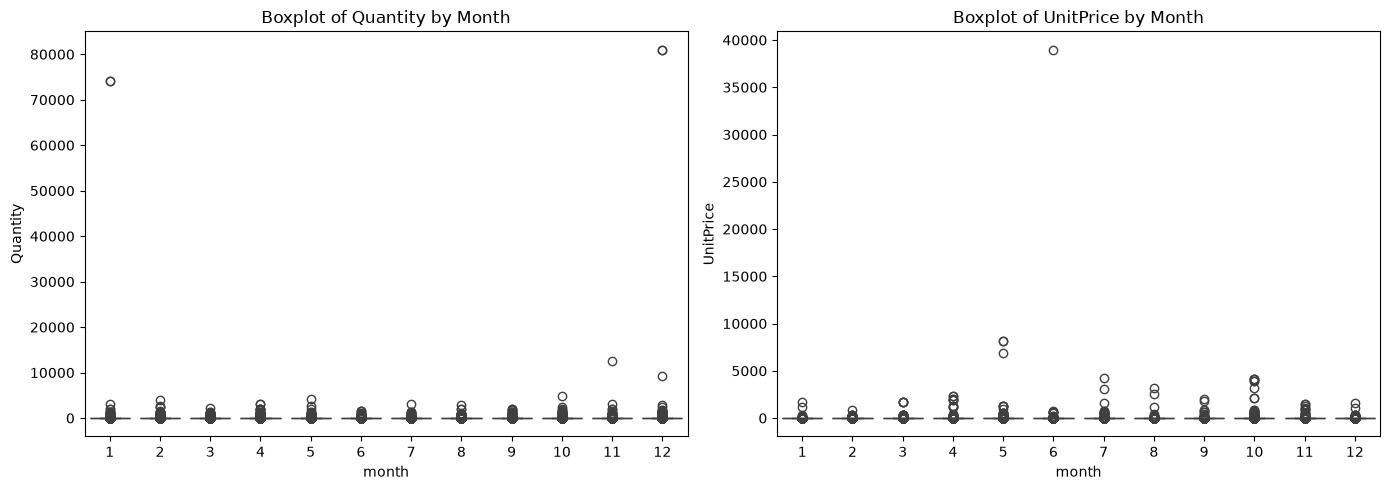

In [22]:
list_ = ['Quantity', 'UnitPrice']

# Tạo khung hình gồm 1 hàng và 2 cột (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duyệt qua từng cột và gán vào đúng vị trí ô (ax)
for i, col in enumerate(list_):
    sns.boxplot(x=df['month'], y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} by Month')

# Căn chỉnh khoảng cách giữa 2 hình cho đẹp mắt
plt.tight_layout()
plt.show()

<Axes: xlabel='month', ylabel='Revenue'>

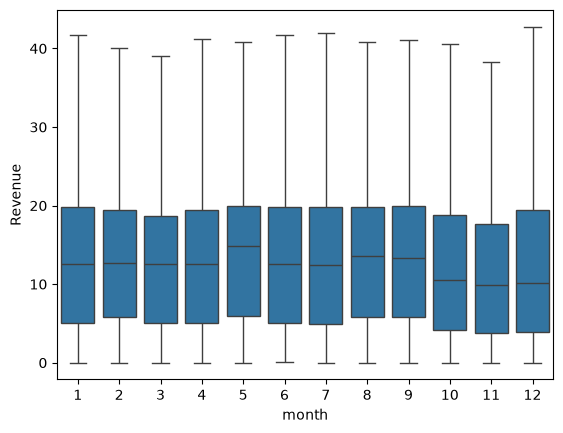

In [23]:
sns.boxplot(x=df['month'], y=df['Revenue'], showfliers=False)

In [24]:
df.shape

(401604, 9)

In [25]:
revenue_by_month = df['Revenue'].groupby(df['month']).sum()

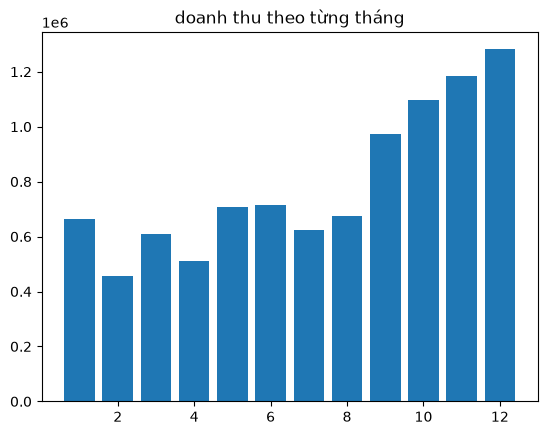

In [26]:
plt.bar(x = revenue_by_month.index, height = revenue_by_month)
plt.title('doanh thu theo từng tháng')
plt.show()

# Cohort Analysis

Khách hàng mua lần đầu vào tháng nào?
Họ quay lại sau bao lâu?
Tỷ lệ giữ chân khách hàng theo từng tháng là bao nhiêu?

Rows: first activity - month of acquisition

Cols: time since first activity - months since acquisition

## 1. Group customers into cohorts based on the month of their first purchase 
## (tìm tháng giao dịch đầu tiên của khách hàng)

In [27]:

# 1. Đưa toàn bộ ngày về ngày 1 của tháng
# dt.to_period("M") chuyển đổi toàn bộ mốc thời gian dạng datetime thành một đối tượng chu kỳ (Period) cấp tháng (M = Month). ví dụ: 2010-12
# hàm này sẽ lấy ngày 01 và 00:00:00 của tháng đó làm mốc chuẩn đại diện cho cả tháng. ví dụ: 2010-12-01 00:00:00
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

# 2. Tìm ngày đầu tháng của đơn hàng ĐẦU TIÊN của từng khách hàng (Cohort Month)
grouping = df.groupby('CustomerID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min') # .transform('min') trả về min InvoiceMonth ứng theo số lượng row bằng với số lượng gốc. 
df.head()

,Quantity,InvoiceDate,UnitPrice,Country,CustomerID,month,day,year,Revenue,InvoiceMonth,CohortMonth
0,6,2010-12-01 08:26:00,2.55,United Kingdom,17850.0,12,1,2010,15.30,2010-12-01,2010-12-01
1,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01
2,8,2010-12-01 08:26:00,2.75,United Kingdom,17850.0,12,1,2010,22.00,2010-12-01,2010-12-01
3,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01
4,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01


## 2. Define a cohort analysis
## Tạo ra pivot table với 
#### index: là tháng đầu tiên mua (đã có ở bước trên)
#### column: là các tháng tiếp theo (phép tính chênh lệch)
#### value: là số lượng khách hàng (tính số lượng unique CustomerID ứng theo index & column)

In [28]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day # tuple data type

### Calculate time offset in days

In [29]:
# 1. Trích xuất Năm (year) và Tháng (month) của thời điểm khách hàng mua lần đầu (CohortMonth)
cohort_year, cohort_month, _ = get_date_int(df, 'CohortMonth')

# 2. Tính chênh lệch số năm giữa thời điểm giao dịch hiện tại và thời điểm mua lần đầu
years_diff = df['year'] - cohort_year

# 3. Tính chênh lệch số tháng giữa thời điểm giao dịch hiện tại và thời điểm mua lần đầu
months_diff = df['month'] - cohort_month

# 4. Quy đổi tổng chênh lệch thời gian ra số tháng (Cohort Index):
#    - years_diff * 12: Đổi khoảng cách năm ra tháng.
#    - + months_diff: Cộng thêm khoảng cách tháng lẻ.
#    - + 1: Tăng mốc bắt đầu lên 1 (Tháng mua hàng đầu tiên được tính là Month 1 thay vì Month 0).
df['CohortIndex'] = years_diff * 12 + months_diff + 1

# 5. Hiển thị 5 dòng đầu tiên của DataFrame để kiểm tra kết quả
df.head()

,Quantity,InvoiceDate,UnitPrice,Country,CustomerID,month,day,year,Revenue,InvoiceMonth,CohortMonth,CohortIndex
0,6,2010-12-01 08:26:00,2.55,United Kingdom,17850.0,12,1,2010,15.30,2010-12-01,2010-12-01,1
1,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01,1
2,8,2010-12-01 08:26:00,2.75,United Kingdom,17850.0,12,1,2010,22.00,2010-12-01,2010-12-01,1
3,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01,1
4,6,2010-12-01 08:26:00,3.39,United Kingdom,17850.0,12,1,2010,20.34,2010-12-01,2010-12-01,1


### Count monthly active customers from each cohort

In [30]:
# tính số lượng khách (unique customerID)
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'], as_index = False)['CustomerID'].nunique()

# tạo bảng pivot_table
cohort_counts = cohort_data.pivot(
                                     index = 'CohortMonth',
                                     columns = 'CohortIndex',
                                     values = 'CustomerID'
                                                )
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02-01,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03-01,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04-01,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05-01,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Retention Rate

In [31]:
# 1. Store the 1st column as cohort_sizes
cohort_sizes = cohort_counts.iloc[:,0]
cohort_sizes

CohortMonth
2010-12-01    948.0
2011-01-01    421.0
2011-02-01    380.0
2011-03-01    440.0
2011-04-01    299.0
2011-05-01    279.0
2011-06-01    235.0
2011-07-01    191.0
2011-08-01    167.0
2011-09-01    298.0
2011-10-01    352.0
2011-11-01    321.0
2011-12-01     41.0
Name: 1, dtype: float64

In [32]:
# 2. Divide all values in the cohort_counts table by cohort_sizes
retention = cohort_counts.divide(cohort_sizes, axis = 0)
pivot_table = retention.round(3)
pivot_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.382,0.334,0.387,0.360,0.397,0.380,0.354,0.354,0.395,0.373,0.50,0.274
2011-01-01,1.0,0.240,0.283,0.242,0.328,0.299,0.261,0.257,0.311,0.347,0.368,0.15,NaN
2011-02-01,1.0,0.247,0.192,0.279,0.268,0.247,0.255,0.282,0.258,0.313,0.092,NaN,NaN
2011-03-01,1.0,0.191,0.255,0.218,0.232,0.177,0.264,0.239,0.289,0.089,NaN,NaN,NaN
2011-04-01,1.0,0.227,0.221,0.211,0.207,0.237,0.231,0.261,0.084,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.237,0.172,0.172,0.215,0.244,0.265,0.104,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.209,0.187,0.272,0.247,0.336,0.102,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.209,0.204,0.230,0.272,0.115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.251,0.251,0.251,0.138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.1 Average Item Per Order

In [33]:
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['Quantity'].mean()
cohort_data = cohort_data.reset_index()
AIPO = cohort_data.pivot(
                                     index = 'CohortMonth',
                                     columns = 'CohortIndex',
                                     values = 'Quantity'
                                                )
AIPO_pivot_table= AIPO.round(1)
AIPO_pivot_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,12.4,15.2,15.5,15.5,13.6,14.7,15.9,15.5,18.6,17.4,19.1,13.7,15.2
2011-01-01,24.3,13.0,12.6,18.9,12.5,15.2,14.7,14.7,11.6,10.7,9.4,9.9,NaN
2011-02-01,11.1,12.7,18.8,12.1,12.8,12.2,13.5,13.2,10.7,12.4,13.0,NaN,NaN
2011-03-01,9.9,11.5,13.5,9.9,13.2,12.8,13.5,14.8,11.2,9.4,NaN,NaN,NaN
2011-04-01,10.0,10.3,9.6,12.1,11.7,8.6,9.9,9.6,7.5,NaN,NaN,NaN,NaN
2011-05-01,11.6,9.5,14.4,11.9,11.2,8.8,10.8,216.7,NaN,NaN,NaN,NaN,NaN
2011-06-01,10.6,14.5,10.7,13.8,10.9,10.0,9.7,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,9.9,13.5,7.3,8.0,6.2,7.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,10.0,6.1,5.4,6.1,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Visualization (Heatmap)

### 4.1. Retention Rate

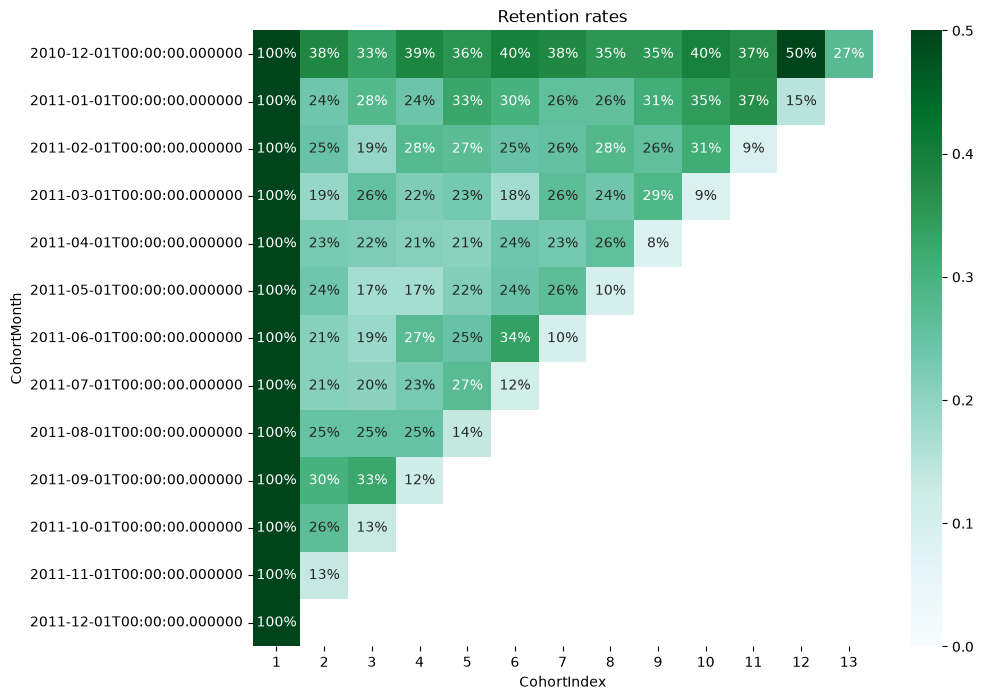

In [34]:
plt.figure(figsize = (10, 8))
plt.title('Retention rates')
sns.heatmap(
    data=pivot_table,  # Dữ liệu đầu vào (thường là một Matrix, DataFrame hoặc Pivot Table)
    annot=True,  # Hiển thị giá trị số trực tiếp lên từng ô của biểu đồ
    fmt=".0%",  # Định dạng hiển thị số dưới dạng phần trăm không có chữ số thập phân (ví dụ: 25%)
    vmin=0.0,  # Giá trị nhỏ nhất của thang màu (tương ứng với 0%)
    vmax=0.5,  # Giá trị lớn nhất của thang màu (tương ứng với 50%, các ô >= 50% sẽ có màu đậm nhất)
    cmap="BuGn",  # Bảng màu hiển thị: kết hợp giữa Blue (Xanh dương) và Green (Xanh lá)
)
plt.show()

### 4.2. Average Item Per Order

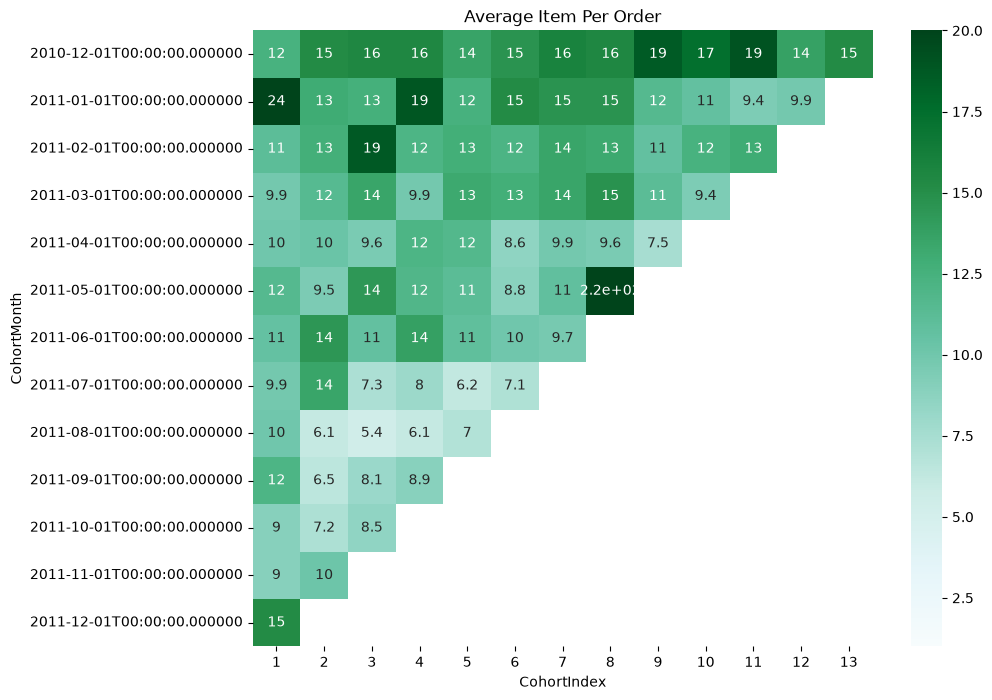

In [35]:
plt.figure(figsize = (10, 8))
plt.title('Average Item Per Order')
sns.heatmap(
    data= AIPO_pivot_table,  # Dữ liệu đầu vào (thường là một Matrix, DataFrame hoặc Pivot Table)
    annot=True,  # Hiển thị giá trị số trực tiếp lên từng ô của biểu đồ
    vmin = 1,  # Giá trị nhỏ nhất của thang màu (tương ứng với 0%)
    vmax = 20,  # Giá trị lớn nhất của thang màu (tương ứng với 50%, các ô >= 50% sẽ có màu đậm nhất)
    cmap="BuGn",  # Bảng màu hiển thị: kết hợp giữa Blue (Xanh dương) và Green (Xanh lá)
)
plt.show()